# Exploratory Data Analysis (EDA) — Understanding Customer Churn

## Objective of this Notebook

The goal of this analysis is to explore the customer dataset and uncover the main drivers behind customer churn.

This notebook focuses on three key objectives:

1. **Understand the churn persona**  
   Identify the characteristics of customers who are more likely to leave the service.

2. **Validate engineered features**  
   Evaluate whether the features created in **Phase 2 (Feature Engineering)** provide meaningful signals.

3. **Generate actionable business insights**  
   Provide recommendations that the **Marketing, Sales, and Customer Success teams** can use to reduce churn.

The insights discovered here will directly guide the **feature selection and modeling strategy in Phase 4 (Machine Learning).**

### Import Libraries and Configure visualization settings

In [22]:
# import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
pd.set_option('display.max_columns', None)

In [23]:
# Work with a copy of the original DataFrame to preserve the raw data
org_df = pd.read_csv("../data/processed/churn_features.csv")
df = org_df.copy()

### Quick overview

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services_count,avg_monthly_spending,spending_spike
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,New,2,54.075000,-0.225000
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,New,0,75.825000,-5.125000
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,New,3,102.562500,-2.912500
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Loyal,4,108.787500,-3.987500
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Very Loyal,4,102.781633,0.918367


In [25]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   object 
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   object 
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   object 
 10  OnlineBackup          7043 non-null   object 
 11  DeviceProtection      7043 non-null   object 
 12  TechSupport           7043 non-null   object 
 13  StreamingTV           7043 non-null   object 
 14  StreamingMovies       7043 non-null   object 
 15  Contract             

,tenure,MonthlyCharges,TotalCharges,Churn,total_services_count,avg_monthly_spending,spending_spike
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,2.037910,64.799424,-0.001213
std,24.559481,30.090047,2266.794470,0.441561,1.847682,30.185891,2.614121
min,0.000000,18.250000,0.000000,0.000000,0.000000,13.775000,-18.900000
25%,9.000000,35.500000,398.550000,0.000000,0.000000,36.179891,-1.159091
50%,29.000000,70.350000,1394.550000,0.000000,2.000000,70.373239,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,3.000000,90.179560,1.145567
max,72.000000,118.750000,8684.800000,1.000000,6.000000,121.400000,19.125000


In [26]:
# Helper function
def plot_churn_rate(data, feature, title, ax=None):
    churn_rate = data.groupby(feature)['Churn'].value_counts(normalize=True).unstack()

    if 'Yes' in churn_rate.columns:
        chart = churn_rate['Yes'].sort_values(ascending=False).plot(kind='bar', color='salmon', ax=ax)
    else:
        chart = churn_rate[1].sort_values(ascending=False).plot(kind='bar', color='salmon', ax=ax)
    
    if ax is None:
        ax = chart

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel(feature)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    if ax is None:
        plt.show()

## 1. Target Variable Analysis (Customer Churn)

>  **Business Question:**  
> What is the current churn rate?  
> Does the dataset suffer from class imbalance that could affect model performance?

Understanding the distribution of the target variable is critical before building any predictive model.  
It helps determine the **baseline performance** and informs which **evaluation metrics** should be used later.

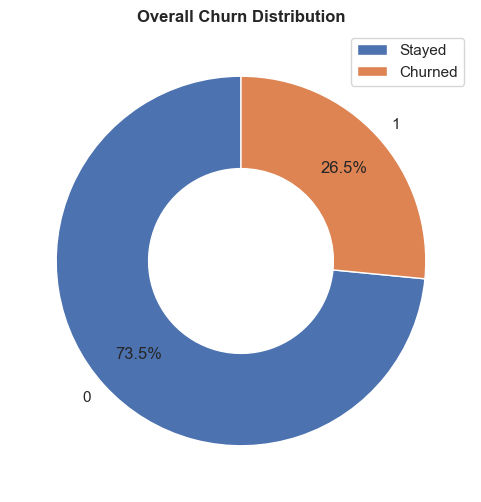

In [27]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', pctdistance=0.75, startangle=90, colors=['#4C72B0', '#DD8452'], wedgeprops=dict(width=0.5))
plt.title('Overall Churn Distribution', fontweight='bold')
plt.ylabel('')
plt.legend(['Stayed', 'Churned'], loc='upper right')
plt.show()

 **Data Insight & Modeling Strategy**

- **Churn Rate:** ~26.5% of customers have churned.  
  This means **more than 1 in 4 customers leave the service**, which is extremely high for a telecom company (industry benchmarks are usually **5–10%**).

- **Class Imbalance:** The dataset shows **moderate class imbalance**.

- **Baseline Accuracy:**  
  If a model predicts **"No Churn" for every customer**, it would still achieve about **73.5% accuracy**.

 Therefore, **Accuracy is not an appropriate metric for this problem.**

Instead, the following metrics will be prioritized in the modeling phase:

- **Recall** (ability to detect churners)
- **F1-score** (balance between precision and recall)
- **PR-AUC** (precision-recall tradeoff)

Additionally, techniques such as **SMOTE or class weighting** may be considered to handle the imbalance.

## 2. Customer Lifecycle Analysis (Tenure)

>  **Business Question:**  
> At what stage of the customer lifecycle are customers most likely to churn?

Customer tenure represents how long a customer has stayed with the company.  
This is often one of the **strongest predictors of churn** in subscription-based businesses.

In Phase 2, we engineered a feature called **`tenure_group`** to segment customers based on their lifecycle stage:

- **New**
- **Regular**
- **Loyal**
- **Very Loyal**

In this section we will:

1. Analyze the **distribution of tenure by churn status**
2. Validate whether **`tenure_group` effectively captures churn behavior**

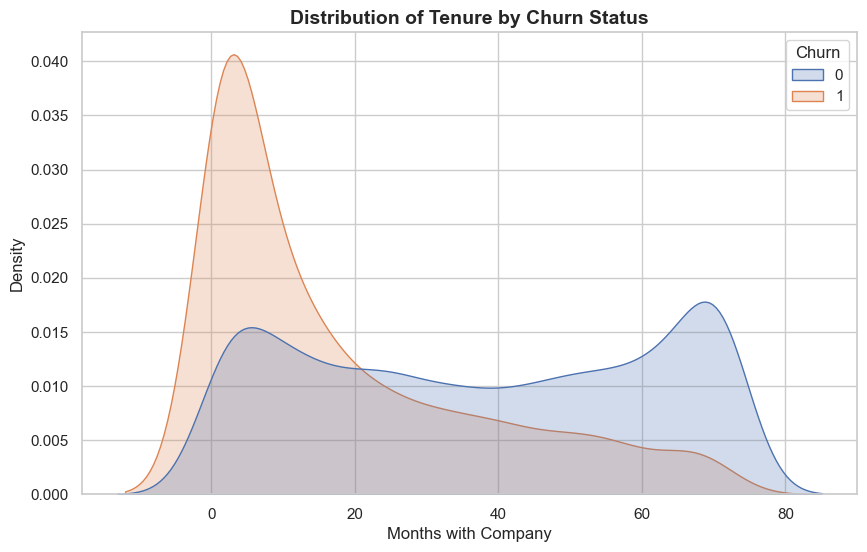

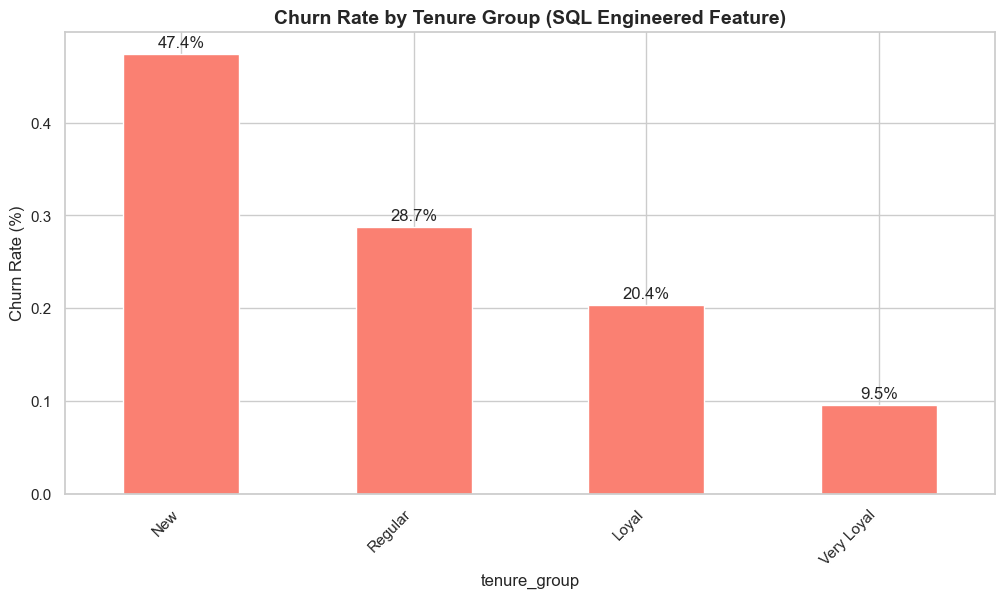

In [28]:
# Use KDE plot to visualize the distribution of 'tenure'
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette=['#4C72B0', '#DD8452'])
plt.title('Distribution of Tenure by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Months with Company')
plt.ylabel('Density')
plt.show()

plot_churn_rate(df, 'tenure_group', 'Churn Rate by Tenure Group (SQL Engineered Feature)')

 **Actionable Insight**

- The KDE distribution clearly shows a **sharp spike of churners in the first 1–6 months**.

- This period represents a **critical churn window**, where customers are still evaluating the service.

- The engineered feature **`tenure_group` successfully captures this behavior**:
  - Customers in the **"New"** segment show a churn rate close to **50%**.

 **Business Recommendation**

The company should introduce a **Customer Onboarding Retention Program**, such as:

- onboarding support in the first months
- engagement campaigns
- targeted discounts in **month 3 and month 6**

The goal is to help new customers **successfully pass the early churn risk period**.

## 3. Pricing and Spending Analysis

>  **Business Question:**  
> Are customers leaving because the service is too expensive?

Pricing is one of the most common drivers of churn in telecom services.  
In this section, we investigate whether **higher monthly costs are associated with higher churn probability**.

We also analyze spending behavior relative to **customer tenure**, which helps reveal patterns such as:

- expensive plans purchased by new customers
- long-term customers paying stable or lower monthly fees

Text(0.5, 1.0, 'Monthly Charges vs Tenure (Colored by Churn)')

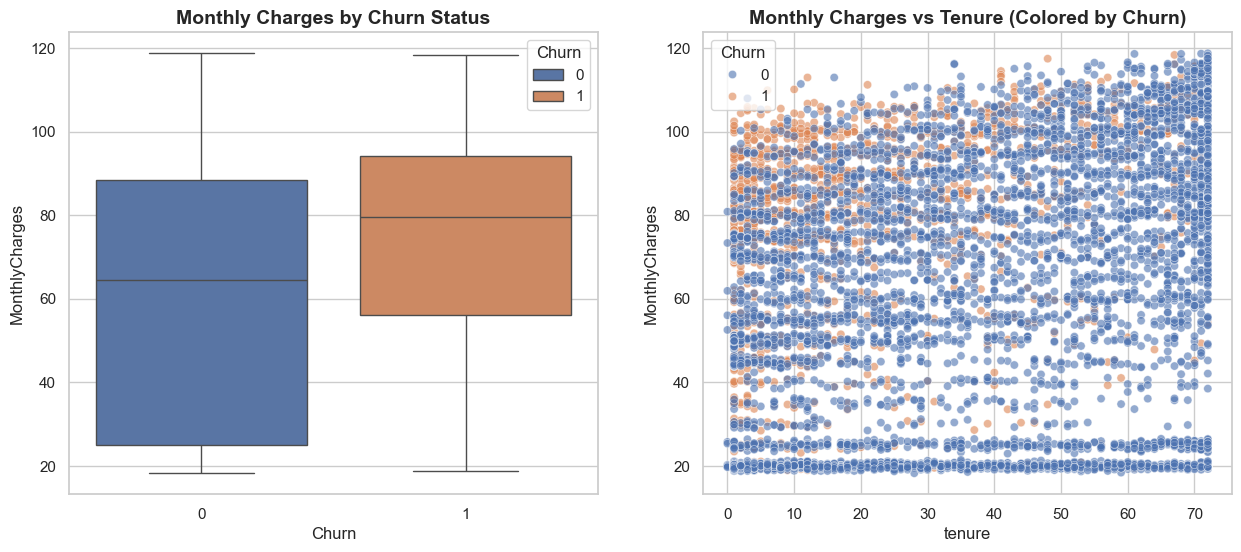

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot for 'MonthlyCharges'
sns.boxplot(data=df, x='Churn', hue='Churn', y='MonthlyCharges', palette=['#4C72B0', '#DD8452'], ax=ax[0])
ax[0].set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')

# Bivariate: Tenure vs. MonthlyCharges
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6, palette=['#4C72B0', '#DD8452'], ax=ax[1])
ax[1].set_title('Monthly Charges vs Tenure (Colored by Churn)', fontsize=14, fontweight='bold')

 **Actionable Insight**

- Customers who churn have **significantly higher monthly charges** than customers who stay  
  (median ≈ **$80 vs $60**).

- The scatter plot reveals a critical cluster:

  **High Monthly Charges + Low Tenure**

  This region contains a dense concentration of churned customers.

This suggests a potential **pricing strategy issue**.

 **Business Recommendation**

The sales strategy may be **over-selling expensive plans to new customers**.

A better approach would be:

1. Start customers with **affordable base plans**
2. Gradually **upsell premium features after customer loyalty increases**

This reduces early churn risk while still maximizing long-term revenue.

## 4. Spending Behavior Analysis (Engineered Feature)

> **Business Question:**  
Does the engineered metric `avg_monthly_spending` reveal additional insights about customer churn?

This feature captures **the average monthly spending throughout the customer's lifecycle**, which may reflect pricing pressure or perceived value.

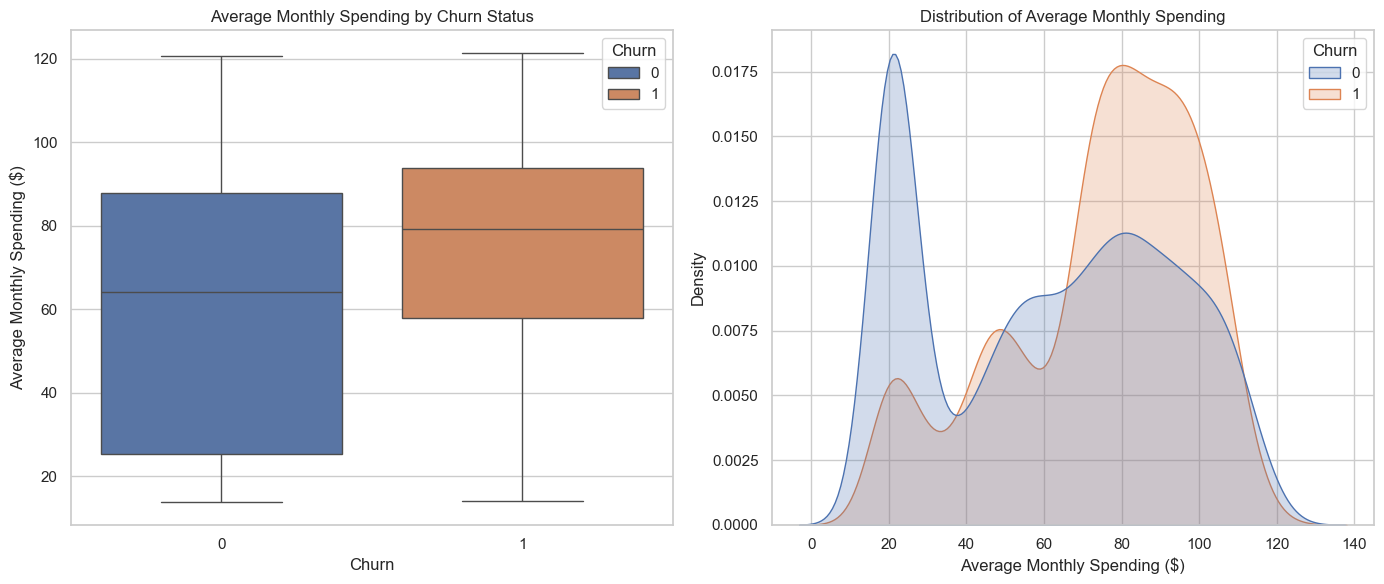

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(
    x="Churn",
    y="avg_monthly_spending",
    hue="Churn",
    data=df,
    palette=["#4C72B0","#DD8452"],
    ax=axes[0]
)

axes[0].set_title("Average Monthly Spending by Churn Status")
axes[0].set_ylabel("Average Monthly Spending ($)")

sns.kdeplot(
    data=df,
    x="avg_monthly_spending",
    hue="Churn",
    fill=True,
    common_norm=False,
    palette=["#4C72B0","#DD8452"],
    ax=axes[1]
)

axes[1].set_title("Distribution of Average Monthly Spending")
axes[1].set_xlabel("Average Monthly Spending ($)")

plt.tight_layout()
plt.show()

**Key Insights**

- Customers who churn tend to have **higher average monthly spending** compared to those who stay.
- The density plot indicates a concentration of churned customers in the **higher spending range**, suggesting potential price sensitivity.

**Business Implication**

High-spending customers may expect higher service value. If expectations are not met, they may switch to competitors. Proactive retention strategies such as **personalized offers or service upgrades** could help retain these customers.

## 5. Spending Spike Analysis (Bill Shock)
>  **Business Question:** `MonthlyCharges` (current) and `avg_monthly_spending` (historical) are usually very similar. However, if the current bill suddenly becomes much higher than the historical average (e.g., promotion ends or plan auto-upgrades), are these customers more likely to churn?

We will create a new variable in the notebook: `spending_spike = MonthlyCharges - avg_monthly_spending`
* `> 0`: Customer is paying more than their historical average (Bill Shock).
* `= 0`: Billing is stable.
* `< 0`: Customer is receiving a discount.

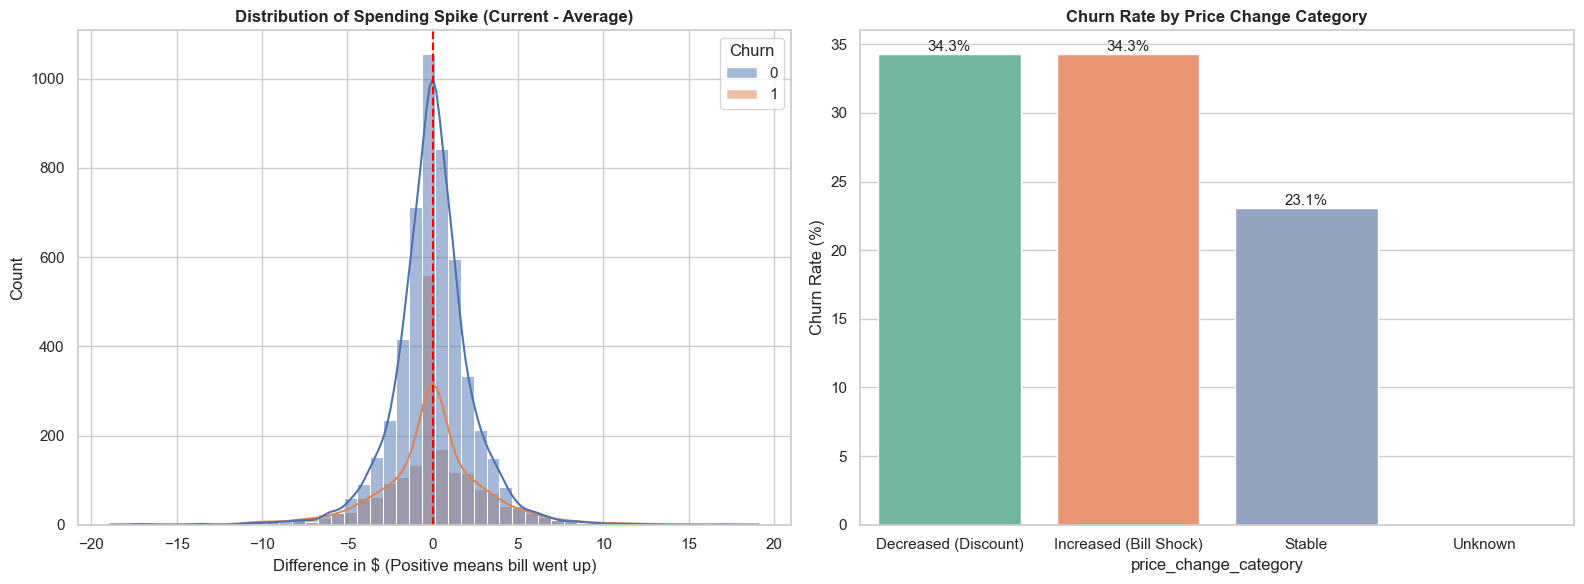

In [39]:
# 1. Create a feature that measures the spending deviation
df['spending_spike'] = df['MonthlyCharges'] - df['avg_monthly_spending']

# 2. Categorize the price change into groups
def categorize_spike(val):
    if pd.isna(val):
        return 'Unknown'
    elif val > 2:   # Bill increased by more than $2
        return 'Increased (Bill Shock)'
    elif val < -2:  # Bill decreased by more than $2
        return 'Decreased (Discount)'
    else:           # Change is not significant
        return 'Stable'

df['price_change_category'] = df['spending_spike'].apply(categorize_spike)

# 3. Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of the deviation
sns.histplot(data=df, x='spending_spike', hue='Churn', bins=50, kde=True, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title('Distribution of Spending Spike (Current - Average)', fontweight='bold')
ax[0].set_xlabel('Difference in $ (Positive means bill went up)')
ax[0].axvline(x=0, color='red', linestyle='--')

# Plot 2: Churn rate by price change category
churn_by_spike = df.groupby('price_change_category')['Churn'].value_counts(normalize=True).unstack()
churn_by_spike = churn_by_spike.iloc[:, 1] * 100  # Take churn rate (Yes) and convert to percentage
sns.barplot(x=churn_by_spike.index, y=churn_by_spike.values, hue=churn_by_spike.index, ax=ax[1], palette='Set2')
ax[1].set_title('Churn Rate by Price Change Category', fontweight='bold')
ax[1].set_ylabel('Churn Rate (%)')

# Add percentage labels
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

 **Actionable Insight & Modeling Strategy:**
* **Detecting "Bill Shock":** While most customers have stable bills (spending spike around 0), the group with **increased bills (Increased)** shows a much higher churn rate. This often happens when promotional pricing ends (e.g., a 6-month trial rate ends and the bill reverts to the standard price). This "bill shock" is a major churn trigger.
* **Feature selection strategy:** 1. `MonthlyCharges` and `avg_monthly_spending` are highly collinear (very strong correlation), so including both in the model can introduce noise.
    2. **Action:** In the modeling phase, keep `MonthlyCharges` (reflects current financial pressure) and add `spending_spike` (the change) as a new feature. Consider dropping `TotalCharges` and `avg_monthly_spending` to keep the model simpler and more stable.

## 6. Contract Type and Payment

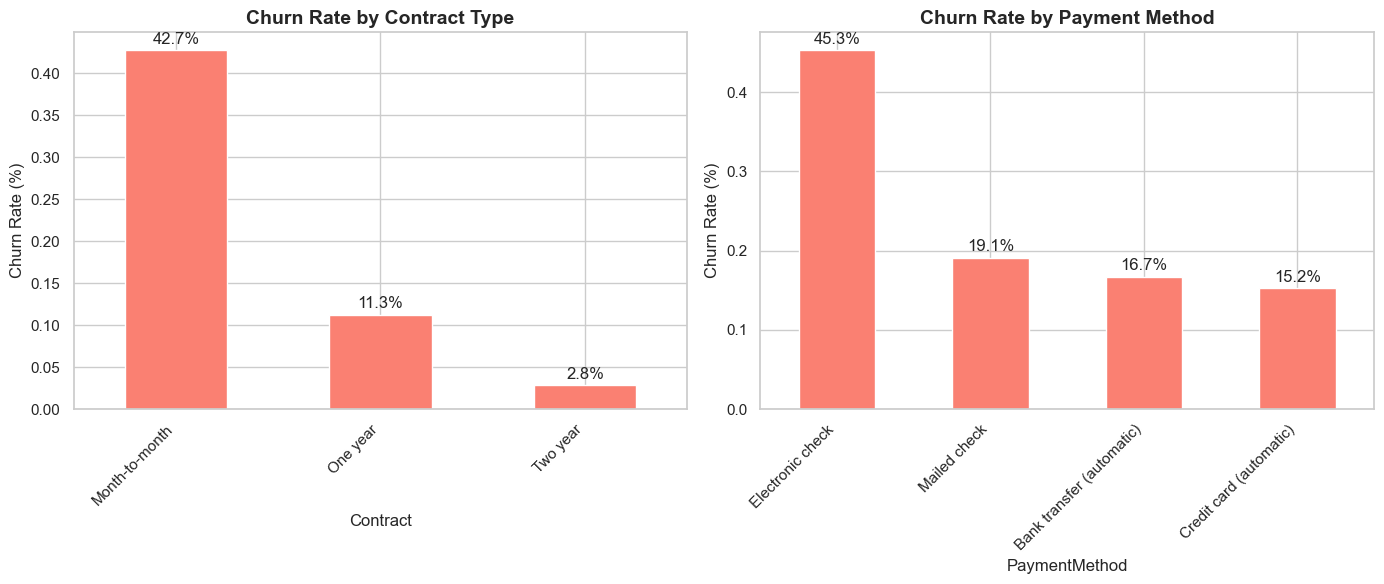

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_churn_rate(df, 'Contract', 'Churn Rate by Contract Type', ax=axes[0])
plot_churn_rate(df, 'PaymentMethod', 'Churn Rate by Payment Method', ax=axes[1])

plt.tight_layout()
plt.show()

 **Actionable Insight**

### Contract Type

Customers with **month-to-month contracts** exhibit an extremely high churn rate (>40%).

In contrast:

- **1-year contracts** show significantly lower churn
- **2-year contracts** show the lowest churn rates (<10%)

This highlights the importance of **customer commitment length**.

### Payment Method

Customers using **Electronic Check** show unusually high churn rates.

Possible explanations include:

- manual payment inconvenience
- payment friction in the platform
- missed or delayed payments

 **Business Recommendation**

1. Offer **discount incentives (e.g., 20%)** for customers who switch from **Month-to-Month to Annual contracts**.

2. Encourage customers to adopt **Auto-Pay methods** such as:
   - Credit Card
   - Bank Transfer

3. The product team should review the **Electronic Check payment UX** for potential usability issues.

## 7. Feature Importance Estimation (Correlation with Target)

To better understand which variables are most associated with churn, we convert all categorical features into **dummy variables** and compute their correlation with the target variable.

This step provides an **early estimate of feature importance** before building machine learning models.

The goal is to identify:

- features that **increase churn probability**
- features that **help retain customers**

In [33]:
# Check for ensuring 'Churn' is binary and has no missing values
df['Churn'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.1 KB


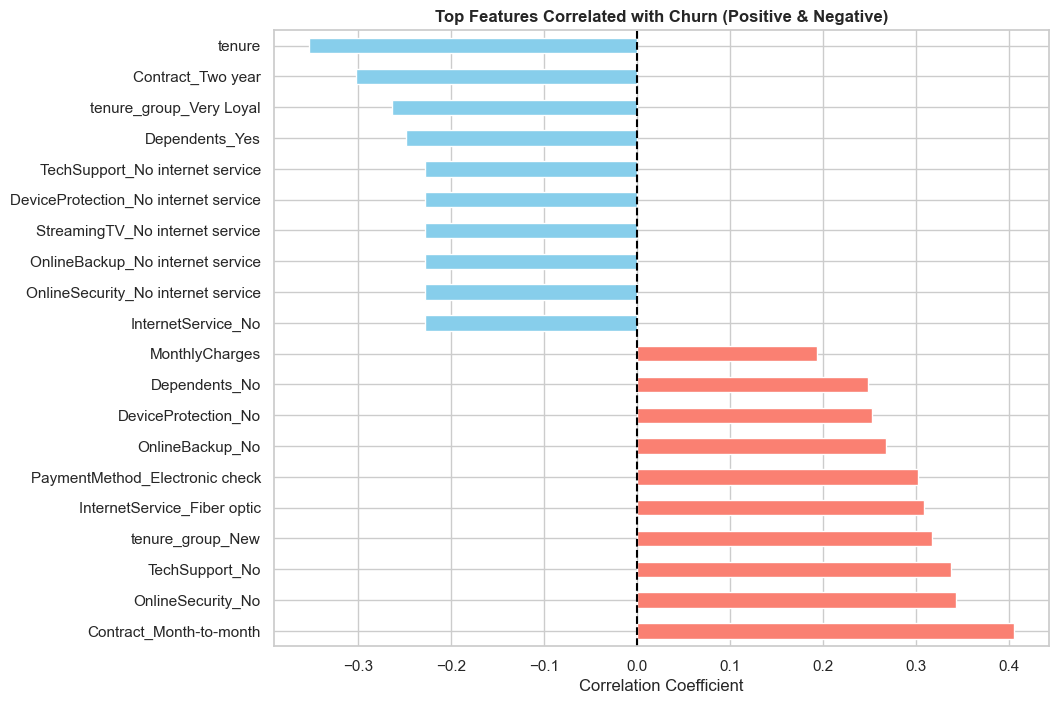

In [34]:
# Create dummy variables for Categorical Features, skip customerID because it's an identifier and not a feature for modeling
df_dummies = pd.get_dummies(df.drop(columns=['customerID'], axis=1, errors = 'ignore'))

# Calculate correlation matrix directly with 'Churn' and drop the 'Churn' column from the correlation matrix to avoid redundancy
corr_with_target = df_dummies.corr()['Churn'].drop('Churn').sort_values(ascending=False)
top_corr = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])

# Visualization
plt.figure(figsize=(10, 8))
top_corr.plot(kind='barh', color=['salmon' if x > 0 else 'skyblue' for x in top_corr])

plt.title('Top Features Correlated with Churn (Positive & Negative)', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

 **Key Takeaways for Machine Learning**

### Top Factors Associated with Higher Churn

The strongest positive correlations include:

- **Month-to-month contracts**
- **Fiber Optic internet service**
- **Electronic Check payment method**
- **Higher Monthly Charges**

These factors significantly increase the likelihood of churn.

### Top Factors Associated with Customer Retention

The strongest negative correlations include:

- **Long customer tenure**
- **Two-year contracts**
- **Higher `total_services_count`**

Interestingly, the engineered feature **`total_services_count`** appears to be a strong retention indicator.

Customers who use more services (security, backup, tech support, etc.) tend to be **more embedded in the ecosystem and less likely to churn**.

This confirms that the **SQL feature engineering performed in Phase 2 successfully captured meaningful behavioral signals**.

## 8. Service Adoption and Customer Stickiness

>  **Business Question:**  
> Does using more services make customers less likely to churn?

Telecom companies often rely on **service bundling strategies** to retain customers.

In Phase 2, we engineered a feature called **`total_services_count`**, representing how many additional services a customer uses (security, backup, tech support, streaming, etc.).

In this section, we evaluate whether **customers using more services demonstrate stronger loyalty**.

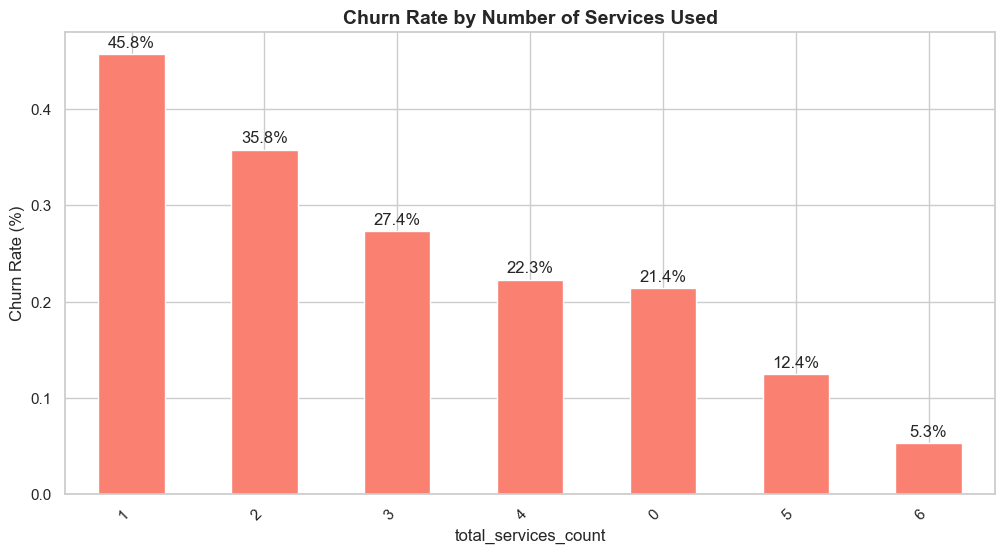

In [35]:
plot_churn_rate(
    df,
    "total_services_count",
    "Churn Rate by Number of Services Used"
)

**Key Insight**

Service adoption is a strong predictor of churn risk:

- Customers using **1–2 services** have the **highest churn rates**, approaching **46%**.
- Churn steadily declines as the number of services increases.
- Customers using **5–6 services** have the **lowest churn rates** (near **5%**).

This points to a clear **service lock-in effect**: the more services a customer uses, the more embedded they become, and the less likely they are to leave.

We also observe an important nuance:

- Customers with **zero additional services** have **moderate churn (~21%)**, which is **lower than the churn rate for customers with only one service**.

This indicates a potential **partial adoption risk**:

- Customers who only adopt **one or two services** may still be in a testing phase and are more likely to churn.
- Customers who adopt **many services (5–6)** are highly retained, suggesting strong ecosystem dependency.


**Business Recommendation**

To reduce churn and increase lifetime value, focus on **deepening engagement with existing customers** by:

- Encouraging adoption of additional services (e.g., security, backup, streaming, tech support)
- Bundling services to promote multi-service usage
- Designing targeted offers for customers with only 1–2 services to accelerate adoption

## 9. Demographic Analysis

>  **Business Question:**  
Do demographic factors such as gender, age group, or family structure influence customer churn?

Understanding these patterns helps identify **customer segments that are more stable or more likely to churn**.

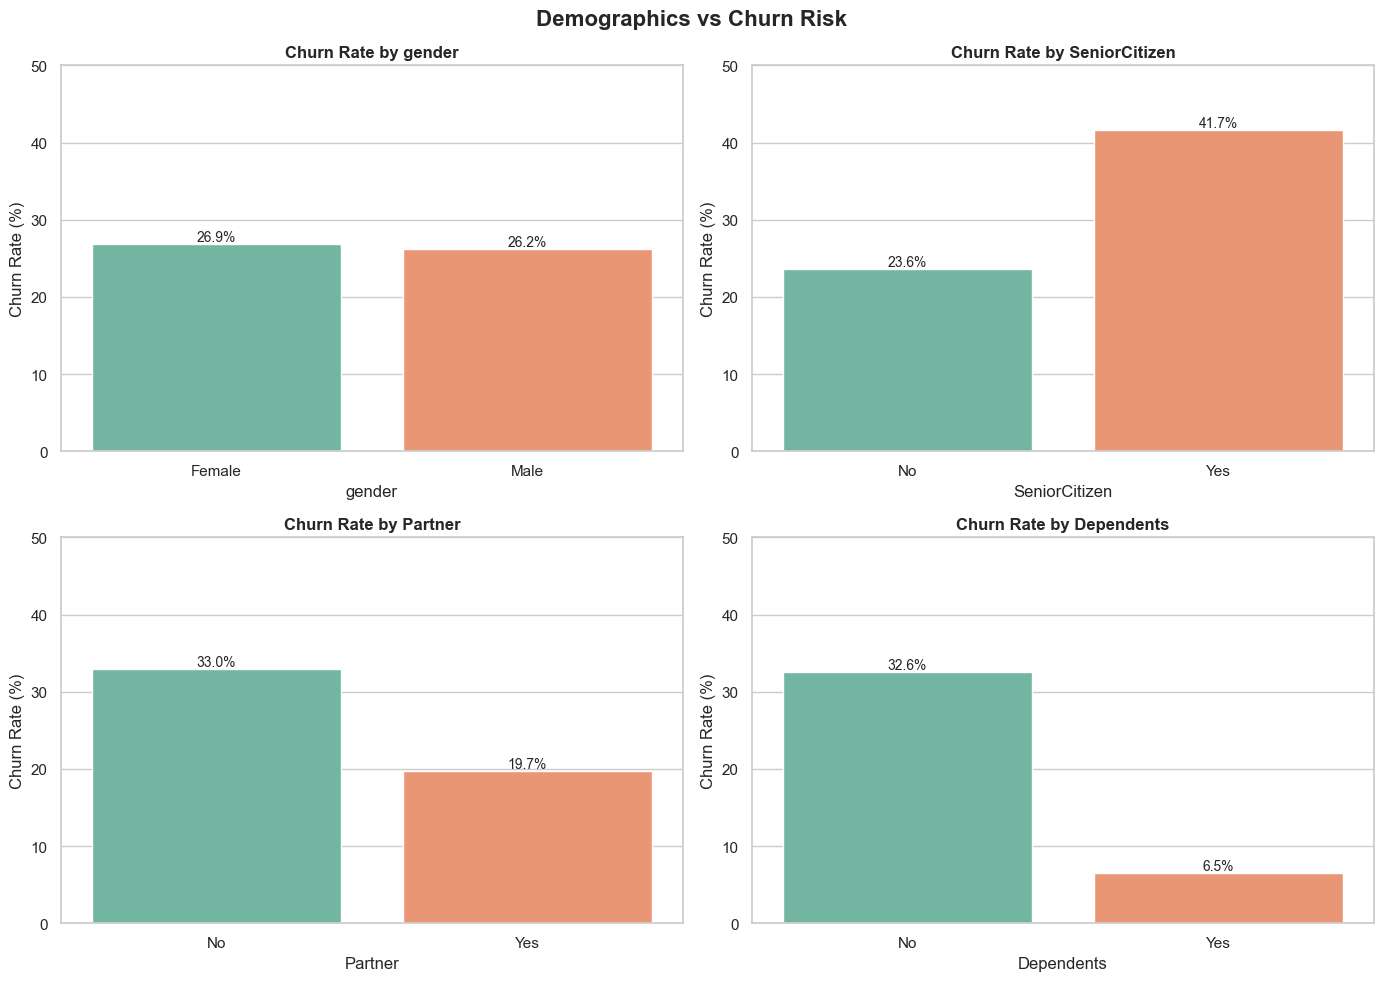

In [37]:
# Create a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demographics vs Churn Risk', fontsize=16, fontweight='bold')

# List of demographic features
demo_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for i, feature in enumerate(demo_features):
    row, col = i // 2, i % 2
    
    # Tính Churn Rate cho từng nhóm
    churn_rate = (
        df.groupby(feature)["Churn"]
        .value_counts(normalize=True)
        .unstack()
    )

    churn_rate = churn_rate.iloc[:, -1] * 100    
    # Vẽ Bar chart
    ax = sns.barplot(x=churn_rate.index, y=churn_rate.values, hue=churn_rate.index, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[row, col].set_ylabel('Churn Rate (%)')
    axes[row, col].set_ylim(0, 50) # Set chung trục y để dễ so sánh
    
    # Add percentage labels
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Key Insights**

- **Gender has little impact on churn.** Male and female customers exhibit almost identical churn rates.
- **Senior citizens show higher churn risk**, suggesting potential issues related to price sensitivity or service complexity.
- **Customers with partners or dependents churn significantly less**, indicating that family households tend to be more stable.

**Business Implication**

Telecom providers could introduce **family bundle plans** or incentives for multi-member households to increase retention.

## 10. Payment Method Analysis

>  **Business Question:**  
Does the way customers pay their bills influence their likelihood to churn?

Payment behavior can reveal **commitment level and potential friction in the payment process**.

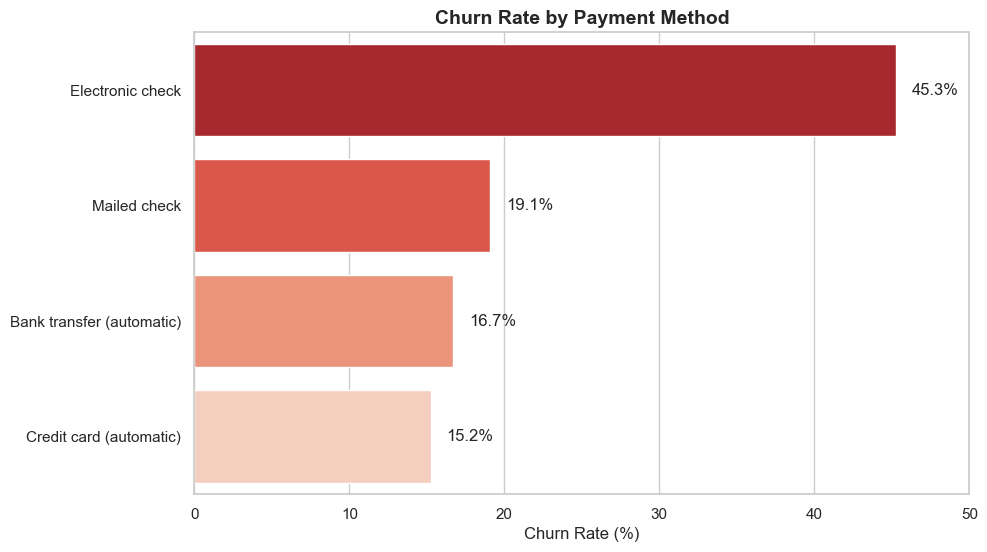

In [38]:
plt.figure(figsize=(10,6))

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .unstack()
)

payment_churn = payment_churn.iloc[:, -1] * 100

payment_churn = payment_churn.sort_values(ascending=False)

ax = sns.barplot(
    x=payment_churn.values,
    y=payment_churn.index,
        hue=payment_churn.index,
        dodge=False,
        ax=plt.gca(),
    palette="Reds_r"
)

plt.title("Churn Rate by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Churn Rate (%)")
plt.ylabel("")

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width()+1, p.get_y()+p.get_height()/2),
        va="center"
    )

plt.xlim(0,50)
plt.show()

**Key Insights**

- Customers using **Electronic Check exhibit the highest churn rate**, significantly higher than other payment methods.
- In contrast, **automatic payment methods (Credit Card or Bank Transfer)** show substantially lower churn rates.

**Business Implication**

Encouraging customers to switch to **automatic billing** could reduce churn. Incentives such as small discounts or loyalty rewards may increase adoption.

## Summary of Key Findings

- **Churn baseline:** ~26.5% of customers churn; this creates a moderate class imbalance that makes accuracy a poor evaluation metric (prefer recall/F1/PR-AUC).
- **Early churn window:** churn peaks in the first 1–6 months, indicating a critical onboarding period.
- **Bill Shock (Spending Spike):** sudden increases in monthly charges (vs historical average) are strongly linked to higher churn.
- **Pricing pressure:** high monthly charges combined with low tenure strongly correlate with churn.
- **Service lock-in:** customers using more services (5–6) have much lower churn (~5%), while customers using only 1–2 services have the highest churn (~46%).
- **Contract & payment risks:** month-to-month contracts and electronic check payments are associated with higher churn.

### Strategic Recommendations

1. **Strengthen onboarding** during months 1–6 with targeted support and engagement.
2. **Promote multi-service adoption** (bundles/upsells) to deepen customer stickiness.
3. **Encourage longer commitments** via incentives for annual/2-year contracts.
4. **Improve payment experience**, especially for electronic checks, to reduce friction.

These insights should guide feature selection and modeling decisions in the next phase of the pipeline.